In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

import sys
import os
import pickle
from tqdm import tqdm
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # second gpu
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

from utils import *

# az.style.use("arviz-docgrid")
plt.rcParams['figure.dpi'] = 140

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv', index_col=0)
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

## LBA

In [3]:
def scale_to_bounds(x, axis=0, eps=1e-3):
    """
    Linearly rescales x along `axis` so that
      min → eps, max → 1-eps,
    and everything else is in between.
    """
    # compute min and max (keepdims so we can broadcast)
    mn = x.min(axis=axis, keepdims=True)
    mx = x.max(axis=axis, keepdims=True)
    # normalize to [0,1]
    x0 = (x - mn) / (mx - mn)
    # stretch to [eps, 1-eps]
    return x0 * (1 - 2*eps) + eps
  
def impute_with_median(data):
    median_rt = np.nanmedian(data)
    rt_imputed = data.copy()
    rt_imputed[rt_imputed == 0] = median_rt
    return rt_imputed

def impute_with_lin_interpolation(data):
    oshape = data.shape
    rt_imputed = data.flatten().copy()
    idx = np.arange(rt_imputed.size)
    good = rt_imputed != 0
    
    # interpolate where values are zero
    rt_imputed[rt_imputed == 0] = np.interp(
        idx[~good], 
        idx[good], 
        rt_imputed[good], 
    )
    return rt_imputed.reshape(oshape)

### Calculating RT and evidence for 5 different choices

In [2]:
r_table 

,Unnamed: 0,subj,sess,run,trial,target,t_calib,resp,resp_err,v_err,...,nn,1sig,2sig,nn_c,att,coh,exp_al,f_onset,f_resp,dir
0,0,0,0,0,0,159.0,145.788047,148.685925,2.897877,2.897877,...,145.788047,1.0,1.0,1.0,-1,1,1.0,132,373,higher
1,1,0,0,0,1,123.0,136.060195,129.253756,6.806439,-6.806439,...,136.060195,1.0,1.0,1.0,1,1,0.0,204,280,lower
2,2,0,0,0,2,51.0,33.954344,124.965094,91.010750,91.010750,...,136.060195,0.0,0.0,0.0,1,1,0.0,168,250,higher
3,3,0,0,0,3,159.0,145.788047,145.702460,0.085587,-0.085587,...,145.788047,1.0,1.0,1.0,-1,1,1.0,168,337,lower
4,4,0,0,0,4,15.0,18.896223,144.334808,125.438585,125.438585,...,145.788047,0.0,0.0,0.0,-1,-1,0.0,180,270,higher
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34555,34555,11,3,5,115,51.0,37.827708,161.360749,123.533041,123.533041,...,153.077094,0.0,0.0,0.0,1,1,NaN,168,292,higher
34556,34556,11,3,5,116,15.0,3.855904,37.650337,33.794433,33.794433,...,37.827708,0.0,0.0,0.0,-1,1,NaN,156,364,higher
34557,34557,11,3,5,117,159.0,153.077094,85.831991,67.245104,-67.245104,...,89.661959,0.0,0.0,0.0,1,-1,NaN,156,401,lower
34558,34558,11,3,5,118,123.0,138.552340,152.674066,14.121726,14.121726,...,153.077094,0.0,1.0,0.0,-1,-1,NaN,156,384,higher


In [6]:
n_trials = r_table.shape[0] // 120
T = 120
rt_raw = (r_table['f_resp'].values - 250).reshape(n_trials, T, 1) * (1000/120)
reaction_time = impute_with_lin_interpolation(rt_raw)
lba_df = pd.DataFrame({
    'rt': reaction_time,
    'target': r_table['target'].map(median_key)
})

ValueError: Per-column arrays must each be 1-dimensional

In [5]:
lba_df

,rt,target
0,1.025000,4
1,0.250000,3
2,0.000000,1
3,0.725000,4
4,0.166667,0
...,...,...
34555,0.350000,1
34556,0.950000,0
34557,1.258333,4
34558,1.116667,3


### Splitting data

In [10]:
import os
import sys
import numpy as np
import pandas as pd
module_path = os.path.abspath('..')
if module_path not in sys.path:
    sys.path.append(module_path)

import pymc3 as pm
from psireact import lba, model

In [11]:
# Masks
low_coherence_mask = r_table["coh"] == -1
high_coherence_mask = r_table["coh"] == 1

divided_attention_mask = r_table["att"] == -1
focused_attention_mask = r_table["att"] == 1

unexpected_mask = r_table["exp_al"] == 0
expected_mask = r_table["exp_al"] == 1

In [13]:
def recover_param_from_mask(mask):
    
    masked_df = lba_df[mask]
    
    # drop row if rt is 0
    masked_df = masked_df[masked_df.rt != 0]
    
    # randomly sample 100 rows from the masked_df
    masked_df = masked_df.sample(n=100, random_state=0)
    
    lba_model = lba.LBA()

    n_trial = len(mask)
    data = {'rt': masked_df.rt.to_numpy(), 'response': masked_df.target.to_numpy(), 
            'test': np.ones(n_trial, dtype='int32')}
    
    with pm.Model() as graph:
        s = 1
        tau = 0
        b = 1
        A = pm.Uniform('A', lower=0, upper=b)
        v = pm.Uniform('v', lower=0, upper=10, shape=5)
        param = {'A': A, 'b': b, 'v': v, 's': s, 'tau': tau}
        def logp(rt, response, test):
            p = lba_model.tensor_pdf(rt, response, test, param)
            return model.log_prob(p)
        t_resp = pm.DensityDist('t_resp', logp, observed=data)

    trace = pm.sample(500, tune=500, model=graph, cores=150, chains=2)
    
    fixed = {'s': 1, 'tau': 0, 'b': 1}
    group_vars = ['A', 'v']
    param, subj_param = model.post_param(trace, fixed, group_vars)
    
    return param, subj_param

In [ ]:
# do this for all masks and store the results in a dictionary
param_dict = {}
subj_param_dict = {}

for mask_name, mask in zip(
    ['low_coherence_mask', 
     'high_coherence_mask', 
     'divided_attention_mask', 
     'focused_attention_mask', 
     'unexpected_mask', 
     'expected_mask'], 
    [low_coherence_mask, 
     high_coherence_mask, 
     divided_attention_mask, 
     focused_attention_mask, 
     unexpected_mask, 
     expected_mask]):
    
    param, subj_param = recover_param_from_mask(mask)
    param_dict[mask_name] = param
    subj_param_dict[mask_name] = subj_param

The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
/home/nuttidalab/miniconda3/envs/psireact/lib/python3.8/site-packages/deprecat/classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 150 jobs)
NUTS: [v, A]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 55 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
/home/nuttidalab/miniconda3/envs/psireact/lib/python3.8/site-packages/deprecat/classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 150 jobs)
NUTS: [v, A]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 67 seconds.
The estimated number of effective samples is smaller than 200 for some parameters.
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
/home/nuttidalab/miniconda3/envs/psireact/lib/python3.8/site-packages/deprecat/classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 150 jobs)
NUTS: [v, A]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 56 seconds.
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
/home/nuttidalab/miniconda3/envs/psireact/lib/python3.8/site-packages/deprecat/classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 150 jobs)
NUTS: [v, A]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 62 seconds.
The acceptance probability does not match the target. It is 0.8976147956911787, but should be close to 0.8. Try to increase the number of tuning steps.
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
/home/nuttidalab/miniconda3/envs/psireact/lib/python3.8/site-packages/deprecat/classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 150 jobs)
NUTS: [v, A]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 65 seconds.
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
/home/nuttidalab/miniconda3/envs/psireact/lib/python3.8/site-packages/deprecat/classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 150 jobs)
NUTS: [v, A]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 58 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 25% for some parameters.


In [19]:
# pickle the param_dict 

# import pickle

# with open('param_dict.pkl', 'wb') as f:
#     pickle.dump(param_dict, f)


### Visualizing the different effects

In [87]:
def plot_lba_schematic_with_params(params, lname):
    s = params['s']
    tau = params['tau']
    b = params['b']
    A = params['A']
    v = params['v']

    n_conditions = len(v)
    fig, axes = plt.subplots(1, n_conditions, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        drift_rate = v[i]

        # Plotting
        ax.axhline(y=b, color='k', linestyle='--', label='Response threshold (b)')
        ax.axhline(y=0, color='k', linewidth=0.5)
        ax.fill_betweenx([0, b], 0, A, color='gray', alpha=0.3, label='Starting point range [0, A]')
        ax.arrow(A/2, 0, drift_rate, b, head_width=0.2, head_length=0.1, fc='black', ec='black', label='Drift rate')

        # Add parameter values to the plot
        scale = 2
        ax.text(0.1, b - 0.5/scale, f'v = {drift_rate:.2f}', fontsize=10, color='black', bbox=dict(facecolor='white', alpha=0.8))
        # ax.text(0.1, b - 0.5/scale, f'b = {b:.2f}', fontsize=10, color='black', bbox=dict(facecolor='white', alpha=0.8))
        # ax.text(0.1, b - 1.0/scale, f'A = {A:.2f}', fontsize=10, color='black', bbox=dict(facecolor='white', alpha=0.8))
        # ax.text(0.1, b - 1.5/scale, f's = {s:.2f}', fontsize=10, color='black', bbox=dict(facecolor='white', alpha=0.8))
        # ax.text(0.1, b - 2.0/scale, f'v = {drift_rate:.2f}', fontsize=10, color='black', bbox=dict(facecolor='white', alpha=0.8))
        # ax.text(0.1, b - 2.5/scale, f'τ = {tau:.2f}', fontsize=10, color='black', bbox=dict(facecolor='white', alpha=0.8))

        # Adding labels and titles
        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-1, b + 1)
        ax.set_title(f'Target {list(reversed(experiment_orientations))[i]}°')
        ax.set_xlabel('Decision Time (s)')
        if i == 0:
            ax.set_ylabel(lname)

        ax.legend(loc='upper left', fontsize=8)
    
    plt.tight_layout()
    plt.show()




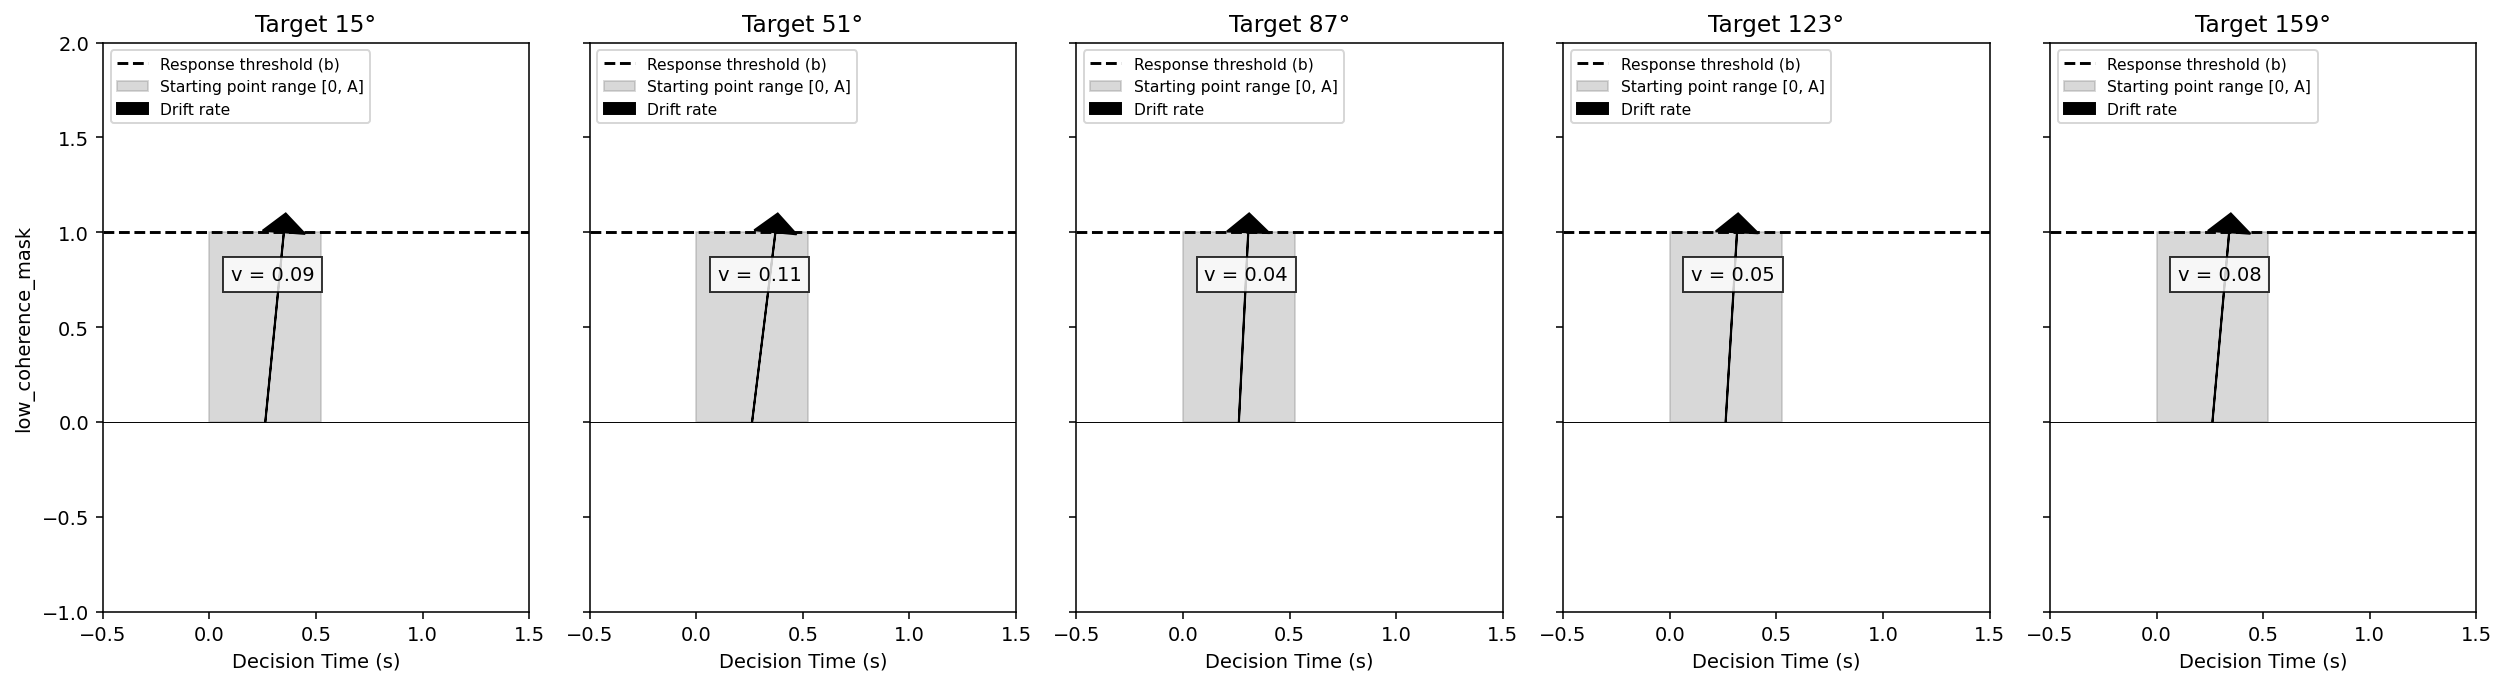

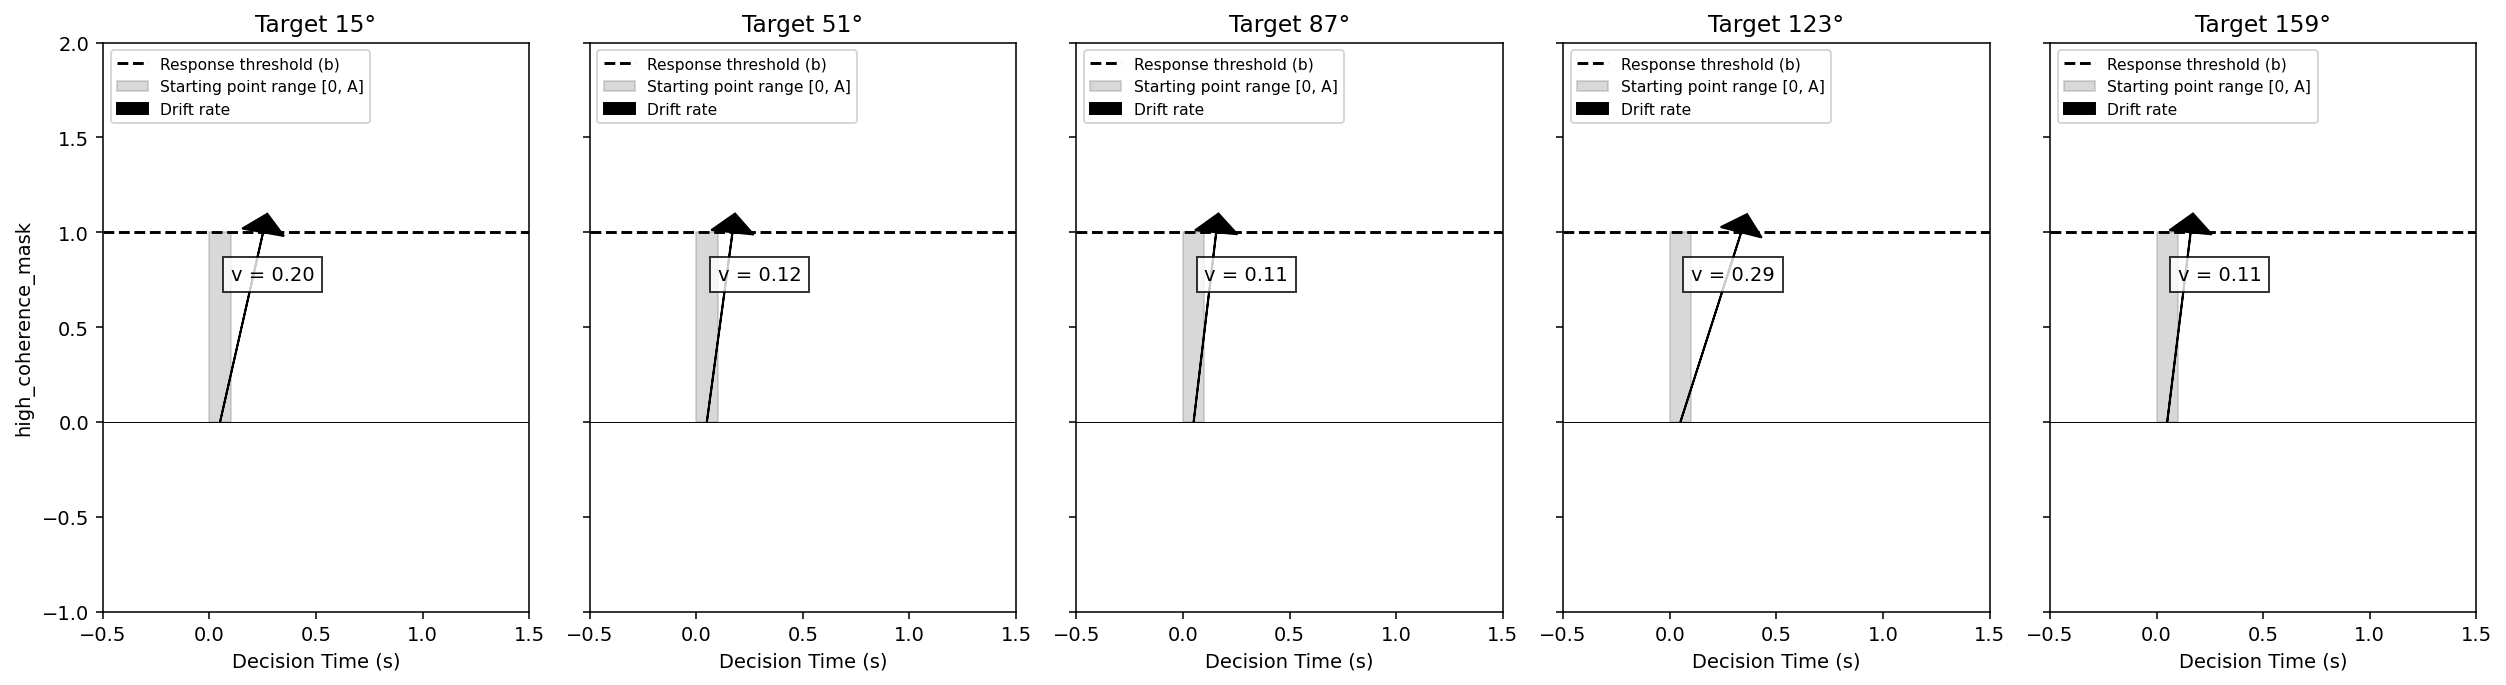

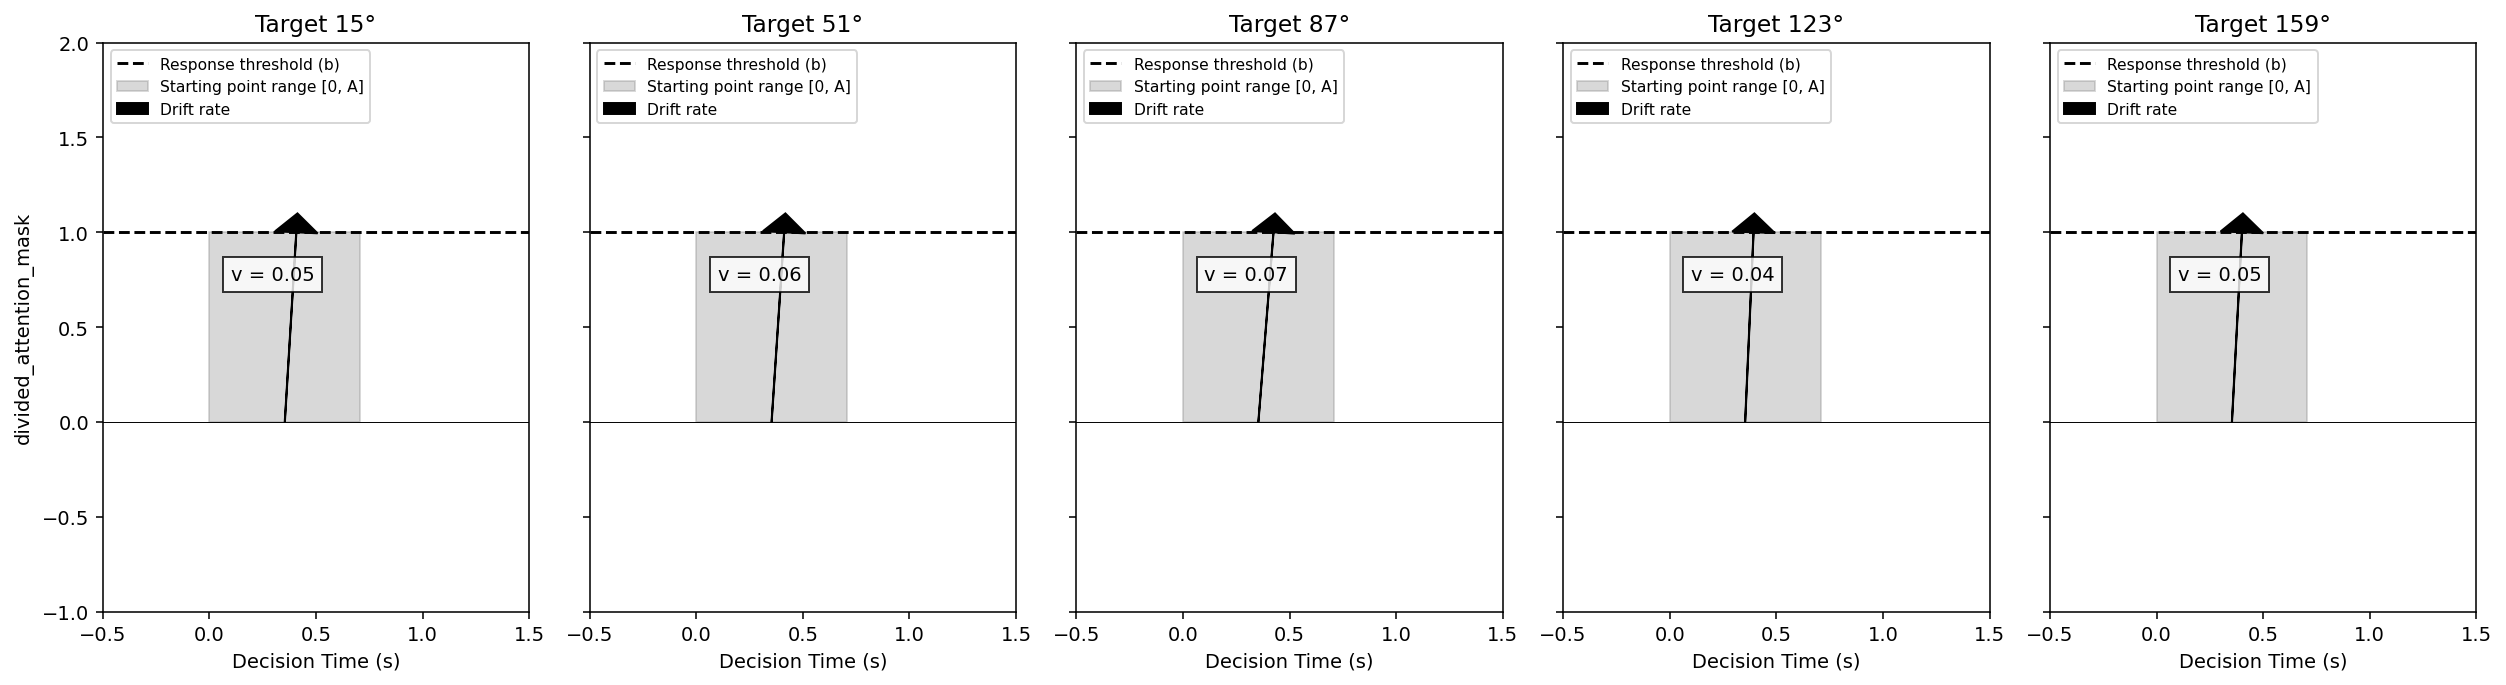

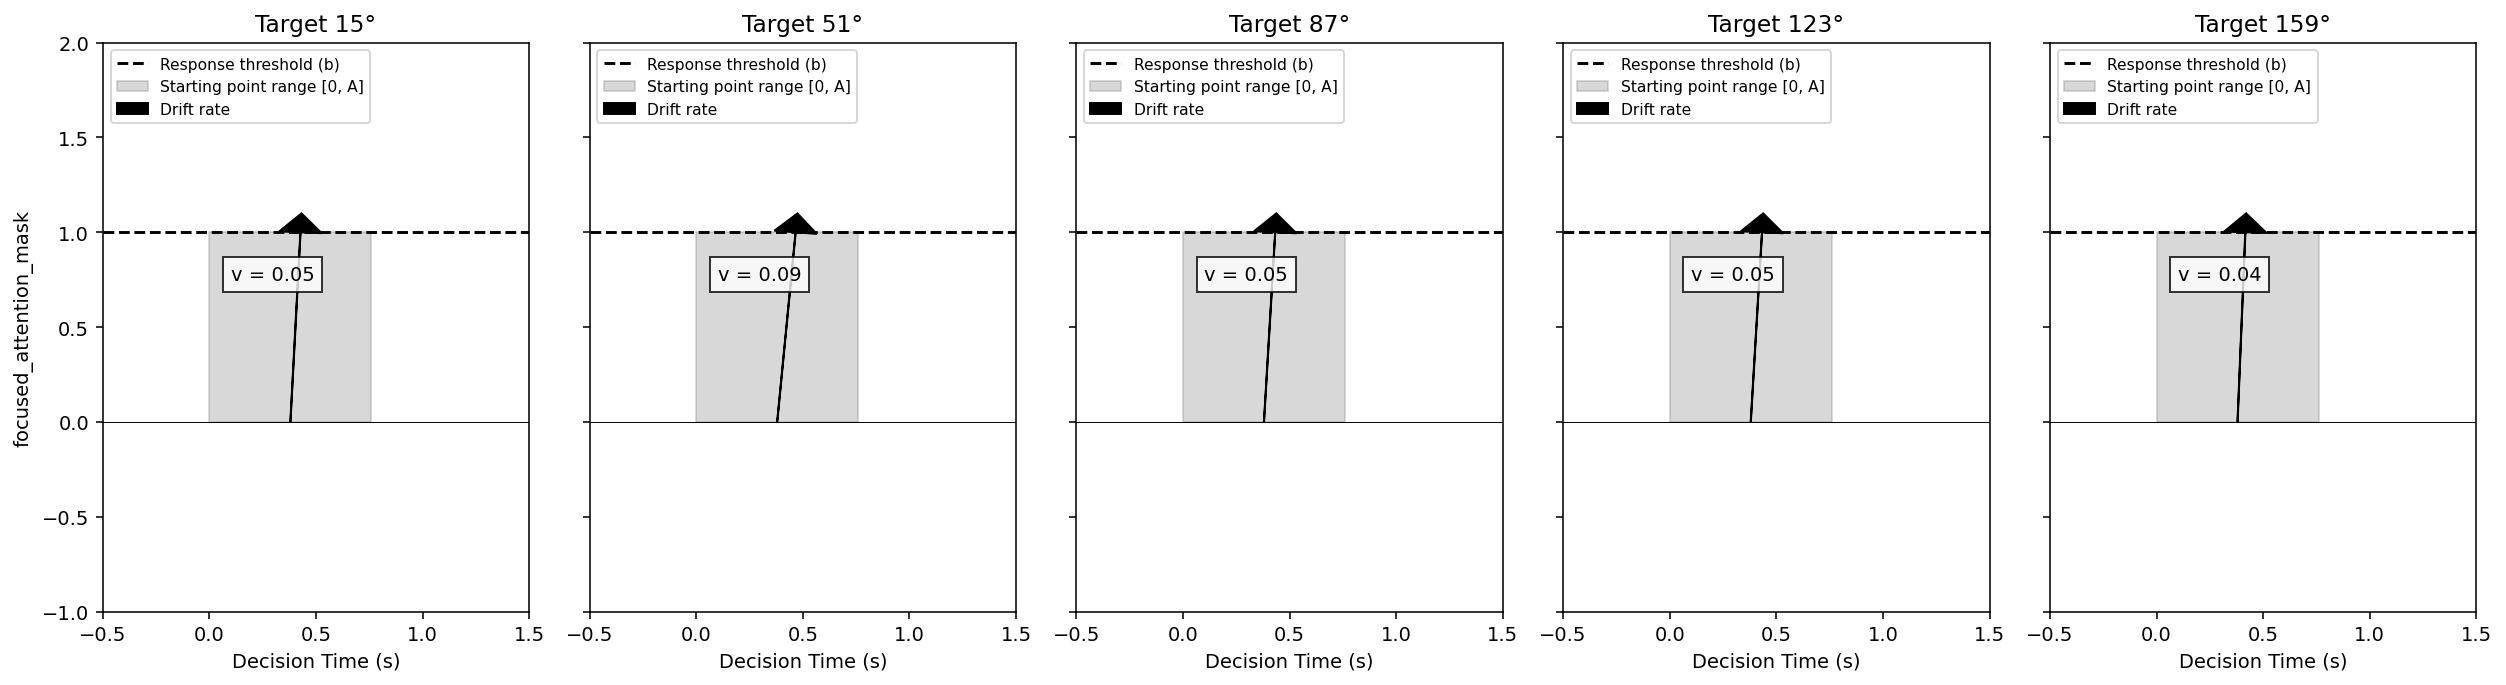

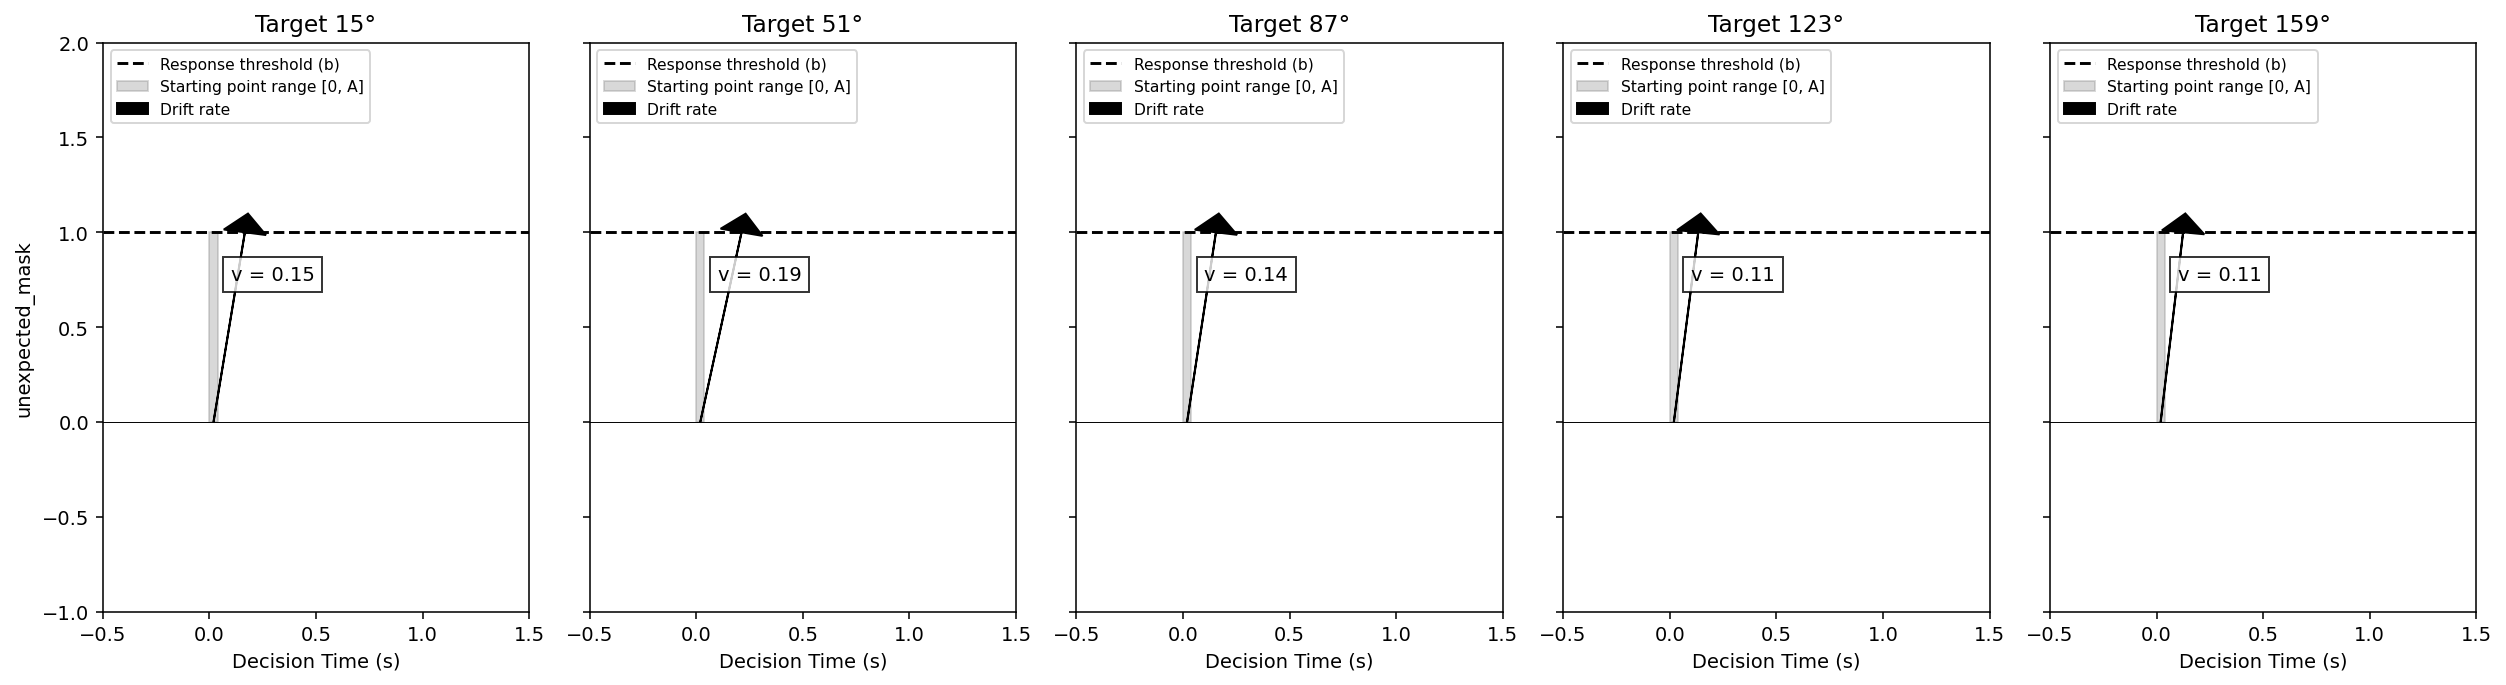

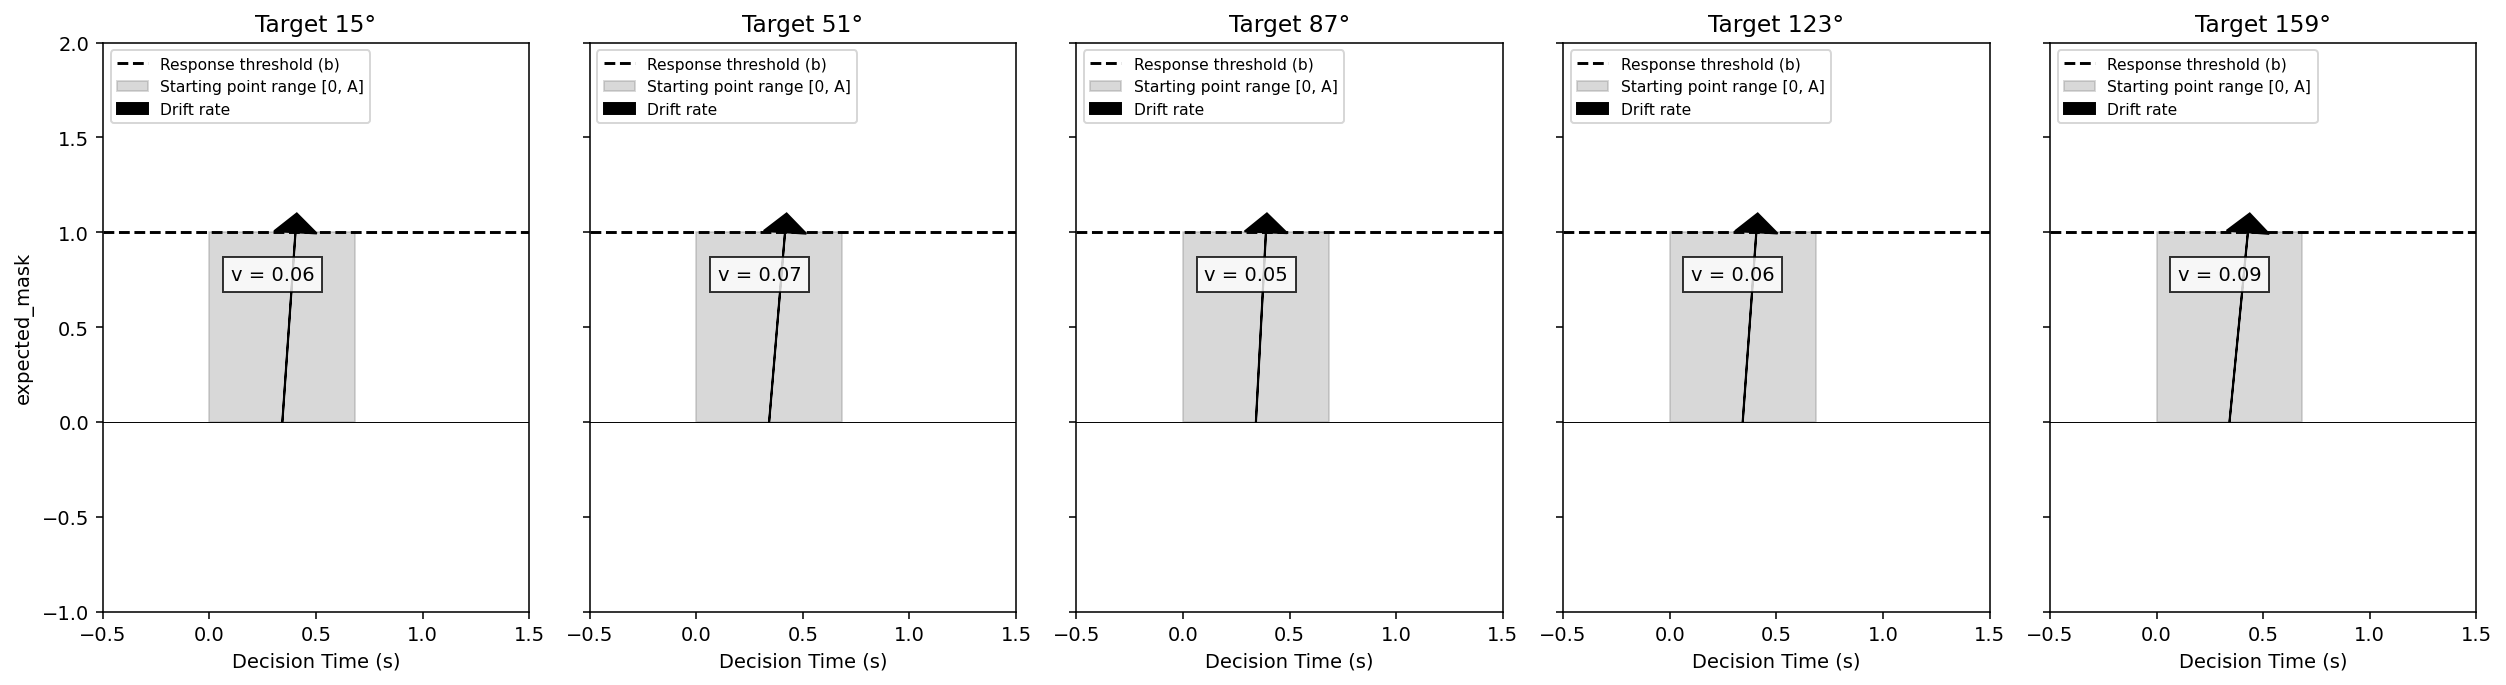

In [88]:
for name in ['low_coherence_mask', 
     'high_coherence_mask', 
     'divided_attention_mask', 
     'focused_attention_mask', 
     'unexpected_mask', 
     'expected_mask']:
    
    # Plot the LBA model schematic with parameter annotations
    plot_lba_schematic_with_params(param_dict[name], lname = name)

In [56]:
drift_rates = []
for name in ['low_coherence_mask', 
     'high_coherence_mask', 
     'divided_attention_mask', 
     'focused_attention_mask', 
     'unexpected_mask', 
     'expected_mask']:
    
    drift_rates.append(param_dict[name]['v'])

drift_rates = np.array(drift_rates)

In [57]:
drift_rates

array([[0.08702272, 0.10938845, 0.04395014, 0.05321208, 0.07835611],
       [0.20184987, 0.12034312, 0.1058649 , 0.28511285, 0.10993799],
       [0.05398509, 0.05887237, 0.07086697, 0.0393688 , 0.04671722],
       [0.04728295, 0.08648435, 0.05268894, 0.05284169, 0.03661132],
       [0.14710949, 0.19346993, 0.13534097, 0.11431051, 0.10524931],
       [0.06151616, 0.07449088, 0.04692294, 0.06385602, 0.08626777]])

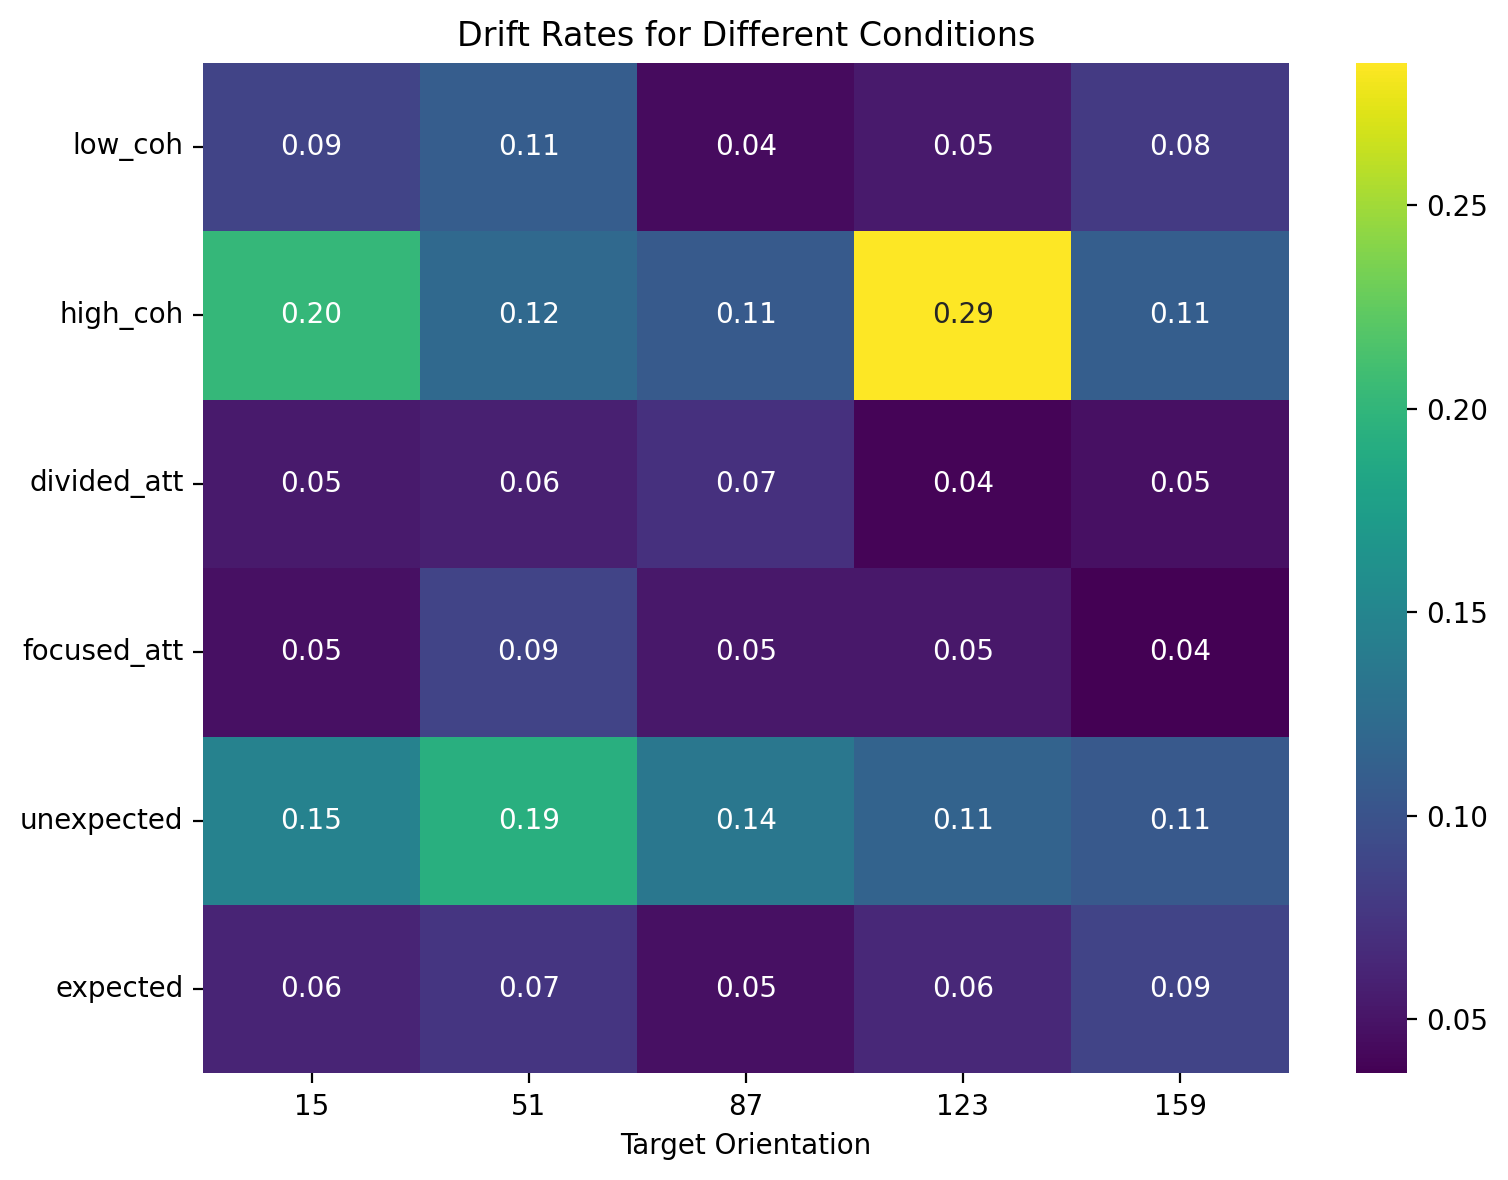

In [72]:
plt.figure(figsize=(8, 6), dpi=200)

sns.heatmap(drift_rates, cmap='viridis', xticklabels=list(reversed(experiment_orientations)), 
            yticklabels=['low_coh', 'high_coh', 'divided_att', 'focused_att', 'unexpected', 'expected'],
            annot=True, fmt=".2f")

plt.xlabel('Target Orientation')
plt.title('Drift Rates for Different Conditions')
plt.tight_layout()

In [85]:
As = []
for name in ['low_coherence_mask', 
     'high_coherence_mask', 
     'divided_attention_mask', 
     'focused_attention_mask', 
     'unexpected_mask', 
     'expected_mask']:
    
    As.append(param_dict[name]['A'])

As = np.array(As)
As

array([0.5242478 , 0.10004084, 0.70719036, 0.75965876, 0.03855907,
       0.68416011])

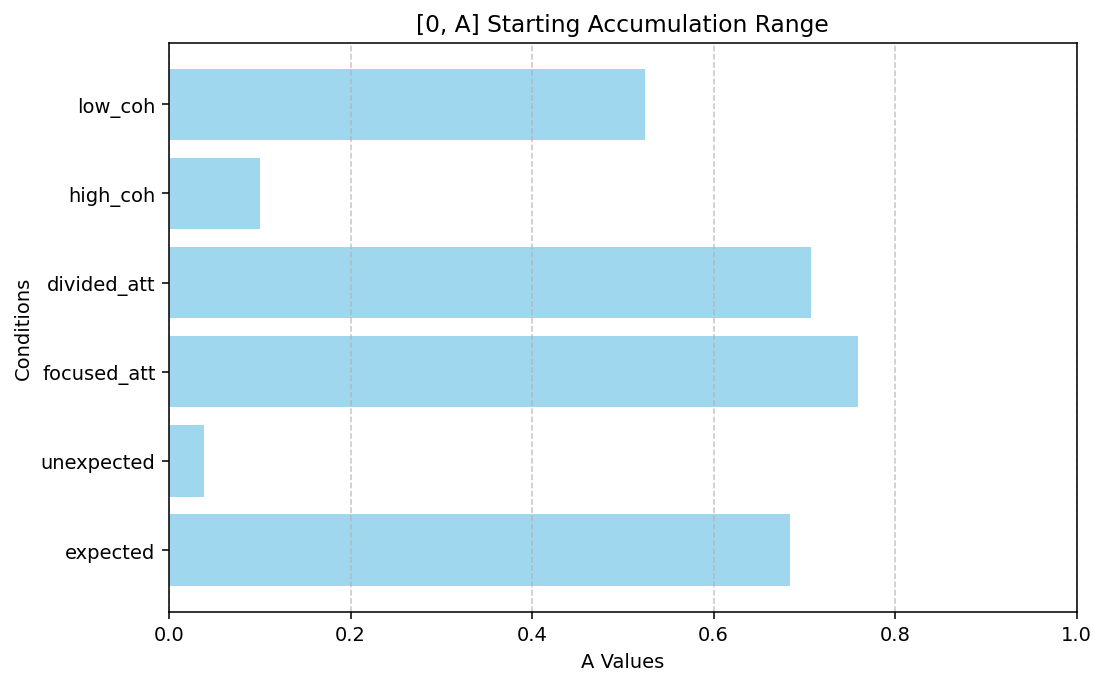

In [95]:
conditions = ['low_coh', 'high_coh', 'divided_att', 'focused_att', 'unexpected', 'expected']

# Plotting a horizontal bar chart for A
plt.figure(figsize=(8, 5))
plt.barh(conditions, As, color='skyblue', alpha=0.8)
plt.gca().invert_yaxis()  # Reverse the order to make bars go left
plt.xlabel('A Values')
plt.ylabel('Conditions')
plt.title('[0, A] Starting Accumulation Range')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()
